In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import xgboost as xgb
import joblib
from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.cluster import DBSCAN

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# point this at the folder containing the 6 CSVs
DATA_DIR = "/mnt/user-data/uploads"
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
def load_historical_prices(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={"STATE": "State", "District Name": "District",
                             "Market Name": "Market", "Price Date": "Date"})
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

    for col in ["State", "District", "Market", "Commodity", "Variety", "Grade"]:
        df[col] = df[col].astype(str).str.strip()

    df = df[(df["Min_Price"] > 0) & (df["Max_Price"] > 0) & (df["Modal_Price"] > 0)]
    df = df[df["Max_Price"] >= df["Min_Price"]]
    df = df.drop_duplicates()
    return df.sort_values("Date").reset_index(drop=True)


def load_price_snapshot(path):
    df = pd.read_csv(path)
    df.columns = [c.replace("_x0020_", " ").strip() for c in df.columns]
    df["Arrival_Date"] = pd.to_datetime(df["Arrival_Date"], format="%d/%m/%Y")
    return df


historical = load_historical_prices(r"C:\Users\Lakshmi\SIH_PROJECT\DATA_DIR\Agriculture_price_dataset_historical.csv")
snapshot = load_price_snapshot(r"C:\Users\Lakshmi\SIH_PROJECT\DATA_DIR\commodity_price.csv")
farmers = pd.read_csv(r"C:\Users\Lakshmi\SIH_PROJECT\DATA_DIR\Farmers_Data.csv")
buyers = pd.read_csv(r"C:\Users\Lakshmi\SIH_PROJECT\DATA_DIR\Buyers_Data.csv")

print(historical.shape, "historical price rows")
print(snapshot.shape, "snapshot price rows (single day, cross-sectional only)")
print(farmers.shape, "farmers")
print(buyers.shape, "buyers")
historical.head()

(736711, 10) historical price rows
(2733, 10) snapshot price rows (single day, cross-sectional only)
(500, 13) farmers
(100, 14) buyers


,State,District,Market,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,2023-06-06
1,Jammu & Kashmir,jammu,Batote,Tomato,Other,FAQ,1800.0,2200.0,2000.0,2023-06-06
2,Gujarat,dahod,Dahod,Wheat,147 Average,FAQ,2500.0,2700.0,2600.0,2023-06-06
3,Madhya Pradesh,guna,Guna(F&V),Tomato,Other,FAQ,350.0,530.0,410.0,2023-06-06
4,Uttar Pradesh,barabanki,Barabanki,Tomato,Hybrid,FAQ,1730.0,1840.0,1780.0,2023-06-06


In [3]:
def add_calendar_features(df, date_col="Date"):
    df = df.copy()
    dt = df[date_col].dt
    df["year"] = dt.year
    df["month"] = dt.month
    df["day"] = dt.day
    df["day_of_week"] = dt.dayofweek
    df["day_of_year"] = dt.dayofyear
    df["week_of_year"] = dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    # cyclical encoding so the model knows Dec is "close to" Jan
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
    return df


def add_lag_rolling_features(df, group_cols, value_col, date_col="Date",
                              lags=(1, 3, 7, 14), windows=(3, 7, 14, 30)):
    """Adds lag_{k} and roll_mean_{w}/roll_std_{w} of value_col within each group,
    sorted by date. Uses shift(1) before rolling so no future info leaks in."""
    df = df.sort_values(date_col).copy()
    grp = df.groupby(group_cols, sort=False)[value_col]

    for k in lags:
        df[f"lag_{k}"] = grp.shift(k)

    shifted = grp.shift(1)
    for w in windows:
        df[f"roll_mean_{w}"] = (
            shifted.groupby([df[c] for c in group_cols]).rolling(w, min_periods=1)
            .mean().reset_index(level=list(range(len(group_cols))), drop=True)
        )
        df[f"roll_std_{w}"] = (
            shifted.groupby([df[c] for c in group_cols]).rolling(w, min_periods=2)
            .std().reset_index(level=list(range(len(group_cols))), drop=True)
        )
    return df


def encode_categoricals(df, cat_cols):
    df = df.copy()
    dtypes = {}
    for col in cat_cols:
        df[col] = df[col].astype("category")
        dtypes[col] = df[col].dtype
    return df, dtypes


def apply_categorical_dtypes(df, dtypes):
    df = df.copy()
    for col, dtype in dtypes.items():
        df[col] = df[col].astype(dtype)
    return df

In [4]:
print(historical.columns.tolist())

['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Date']


In [5]:
#Price Prediction
PRICE_CAT_COLS = ["State", "District", "Market", "Commodity", "Variety", "Grade"]
PRICE_GROUP_COLS = ["Commodity", "Market"]
PRICE_TARGET = "Modal_Price"

PRICE_FEATURE_COLS = PRICE_CAT_COLS + [
    "Min_Price", "Max_Price",
    "year", "month", "day", "day_of_week", "day_of_year", "week_of_year", "is_weekend",
    "month_sin", "month_cos", "doy_sin", "doy_cos",
    "lag_1", "lag_3", "lag_7", "lag_14",
    "roll_mean_3", "roll_std_3", "roll_mean_7", "roll_std_7",
    "roll_mean_14", "roll_std_14", "roll_mean_30", "roll_std_30",
]

def build_price_dataset(raw):
    df = add_calendar_features(raw, "Date")
    df = add_lag_rolling_features(df, PRICE_GROUP_COLS, PRICE_TARGET, "Date")
    fallback = (df["Min_Price"] + df["Max_Price"]) / 2
    lag_roll_cols = [c for c in df.columns if c.startswith(("lag_", "roll_mean_"))]
    df[lag_roll_cols] = df[lag_roll_cols].fillna(fallback, axis=0)
    std_cols = [c for c in df.columns if c.startswith("roll_std_")]
    df[std_cols] = df[std_cols].fillna(0)
    return df

price_df = build_price_dataset(historical)
price_df, price_cat_dtypes = encode_categoricals(price_df, PRICE_CAT_COLS)
price_df.shape

(736711, 33)

In [6]:
X = price_df[PRICE_FEATURE_COLS]
y = price_df[PRICE_TARGET]

df_sorted = price_df.sort_values("Date")
cutoff_date = df_sorted.iloc[int(len(df_sorted) * 0.85)]["Date"]

X_train, X_test = X[price_df["Date"] < cutoff_date], X[price_df["Date"] >= cutoff_date]
y_train, y_test = y[price_df["Date"] < cutoff_date], y[price_df["Date"] >= cutoff_date]

price_model = xgb.XGBRegressor(
    n_estimators=600, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_lambda=1.0,
    objective="reg:squarederror", tree_method="hist", enable_categorical=True,
    random_state=42, n_jobs=-1, early_stopping_rounds=30, eval_metric="mae",
)
price_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

preds = price_model.predict(X_test)
print(f"MAE  (Rs/quintal): {mean_absolute_error(y_test, preds):,.2f}")
print(f"MAPE             : {mean_absolute_percentage_error(y_test, preds):.2%}")
print(f"R^2              : {r2_score(y_test, preds):.4f}")

price_model.save_model(f"{MODEL_DIR}/price_xgb.json")
joblib.dump(price_cat_dtypes, f"{MODEL_DIR}/price_xgb_cat_dtypes.pkl")

MAE  (Rs/quintal): 53.63
MAPE             : 3.80%
R^2              : 0.9759


['models/price_xgb_cat_dtypes.pkl']

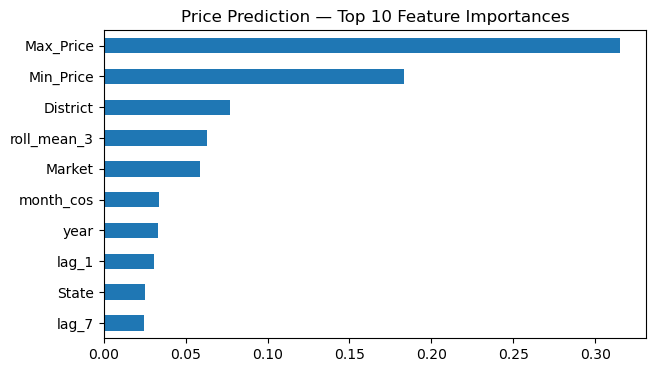

In [7]:
pd.Series(price_model.feature_importances_, index=PRICE_FEATURE_COLS) \
  .sort_values(ascending=False).head(10) \
  .plot(kind="barh", title="Price Prediction — Top 10 Feature Importances", figsize=(7,4)) \
  .invert_yaxis()

In [8]:
def predict_price(model, cat_dtypes, records):
    """records: DataFrame with PRICE_CAT_COLS + Min_Price + Max_Price + Date    (history-derived lag/roll columns are optional; missing ones fall back
    to the same-day price band as a neutral prior)."""
    df = add_calendar_features(records.copy(), "Date")
    fallback = (df["Min_Price"] + df["Max_Price"]) / 2
    for c in PRICE_FEATURE_COLS:
        if c not in df.columns:
            df[c] = 0 if c.startswith("roll_std_") else fallback
    for col, dtype in cat_dtypes.items():
        df[col] = df[col].astype(dtype)
    return model.predict(df[PRICE_FEATURE_COLS])

#  predict tomorrow's Wheat modal price at a market seen in training
sample = historical[(historical["Commodity"] == "Wheat")].iloc[[-1]].copy()
sample_query = sample[["State", "District", "Market", "Commodity", "Variety", "Grade",
                        "Min_Price", "Max_Price"]].copy()
sample_query["Date"] = pd.Timestamp.now().normalize()
print("Predicted Modal_Price:", predict_price(price_model, price_cat_dtypes, sample_query)[0])

Predicted Modal_Price: 2454.2473


In [9]:
#Demand Forecasting
DEMAND_CAT_COLS = ["State", "Commodity"]
DEMAND_GROUP_COLS = ["Commodity", "State"]
DEMAND_TARGET = "demand"

DEMAND_FEATURE_COLS = DEMAND_CAT_COLS + [
    "avg_modal_price",
    "year", "month", "day_of_week", "day_of_year", "week_of_year", "is_weekend",
    "month_sin", "month_cos", "doy_sin", "doy_cos",
    "lag_1", "lag_3", "lag_7", "lag_14",
    "roll_mean_3", "roll_std_3", "roll_mean_7", "roll_std_7",
    "roll_mean_14", "roll_std_14", "roll_mean_30", "roll_std_30",
]

def build_daily_demand_table(raw):
    daily = (
        raw.groupby(["Commodity", "State", "Date"])
        .agg(demand=("Modal_Price", "size"), avg_modal_price=("Modal_Price", "mean"))
        .reset_index()
    )
    filled = []
    for (commodity, state), g in daily.groupby(["Commodity", "State"]):
        g = g.set_index("Date").sort_index()
        full_idx = pd.date_range(g.index.min(), g.index.max(), freq="D")
        g = g.reindex(full_idx)
        g["demand"] = g["demand"].fillna(0)
        g["avg_modal_price"] = g["avg_modal_price"].ffill().bfill()
        g["Commodity"] = commodity
        g["State"] = state
        g.index.name = "Date"
        filled.append(g.reset_index())
    daily = pd.concat(filled, ignore_index=True)

    daily = add_calendar_features(daily, "Date")
    daily = add_lag_rolling_features(daily, DEMAND_GROUP_COLS, DEMAND_TARGET, "Date")

    lag_roll_cols = [c for c in daily.columns if c.startswith(("lag_", "roll_mean_"))]
    daily[lag_roll_cols] = daily[lag_roll_cols].fillna(0)
    std_cols = [c for c in daily.columns if c.startswith("roll_std_")]
    daily[std_cols] = daily[std_cols].fillna(0)
    return daily

demand_df = build_daily_demand_table(historical)
demand_df, demand_cat_dtypes = encode_categoricals(demand_df, DEMAND_CAT_COLS)
demand_df.shape

(45768, 28)

In [10]:
X = demand_df[DEMAND_FEATURE_COLS]
y = demand_df[DEMAND_TARGET]

df_sorted = demand_df.sort_values("Date")
cutoff_date = df_sorted.iloc[int(len(df_sorted) * 0.85)]["Date"]
X_train, X_test = X[demand_df["Date"] < cutoff_date], X[demand_df["Date"] >= cutoff_date]
y_train, y_test = y[demand_df["Date"] < cutoff_date], y[demand_df["Date"] >= cutoff_date]

demand_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
    objective="reg:squarederror", tree_method="hist", enable_categorical=True,
    random_state=42, n_jobs=-1, early_stopping_rounds=30, eval_metric="mae",
)
demand_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

preds = np.clip(demand_model.predict(X_test), 0, None)
nonzero = y_test > 0
print(f"MAE  (lots/day)      : {mean_absolute_error(y_test, preds):,.2f}")
print(f"MAPE (demand>0 rows) : {mean_absolute_percentage_error(y_test[nonzero], preds[nonzero]):.2%}")
print(f"R^2                  : {r2_score(y_test, preds):.4f}")

demand_model.save_model(f"{MODEL_DIR}/demand_xgb.json")
joblib.dump(demand_cat_dtypes, f"{MODEL_DIR}/demand_xgb_cat_dtypes.pkl")

MAE  (lots/day)      : 2.85
MAPE (demand>0 rows) : 35.17%
R^2                  : 0.9375


['models/demand_xgb_cat_dtypes.pkl']

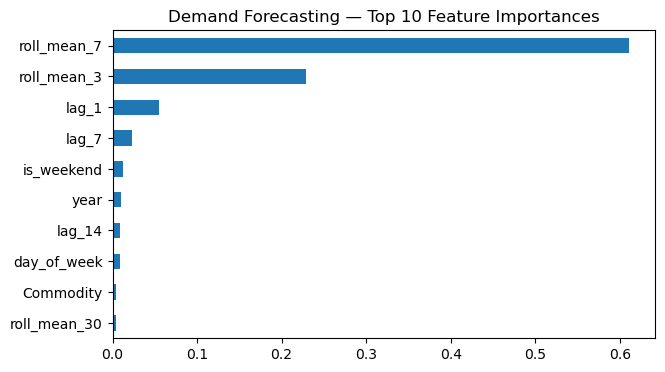

In [11]:
pd.Series(demand_model.feature_importances_, index=DEMAND_FEATURE_COLS) \
  .sort_values(ascending=False).head(10) \
  .plot(kind="barh", title="Demand Forecasting — Top 10 Feature Importances", figsize=(7,4)) \
  .invert_yaxis()

In [12]:
#Buyer Recommendation–
from dataclasses import dataclass

EARTH_RADIUS_KM = 6371.0
GRADE_RANK = {"C": 1, "Grade C": 1, "B": 2, "Grade B": 2,
              "A": 3, "Grade A": 3, "Organic Certified": 4}

@dataclass
class RecommendationWeights:
    price: float = 0.35
    quantity: float = 0.20
    quality: float = 0.15
    distance: float = 0.15
    reliability: float = 0.10
    urgency: float = 0.05
    def as_dict(self):
        return self.__dict__

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))

def _grade_level(g):
    return GRADE_RANK.get(str(g).strip(), 2)

def score_pair(farmer, buyer, today=None, weights=RecommendationWeights(), fair_price=None):
    today = today or pd.Timestamp(datetime.now().date())

    reference_price = farmer["expected_price"]
    if fair_price is not None:
        reference_price = 0.5 * farmer["expected_price"] + 0.5 * fair_price
    price_ratio = buyer["offered_price_per_kg"] / max(reference_price, 1e-6)
    price_score = np.clip(price_ratio, 0, 1.5) / 1.5

    q_ratio = farmer["quantity_kg"] / max(buyer["required_quantity_kg"], 1e-6)
    if q_ratio >= 1:
        quantity_score = np.clip(1 - 0.15 * (q_ratio - 1), 0.3, 1.0)
    else:
        quantity_score = np.clip(q_ratio, 0, 1.0)

    farmer_grade, buyer_grade = _grade_level(farmer["grade"]), _grade_level(buyer["quality_required"])
    quality_score = 1.0 if farmer_grade >= buyer_grade else max(0.0, 1 - 0.35 * (buyer_grade - farmer_grade))

    dist_km = haversine_km(farmer["latitude"], farmer["longitude"], buyer["latitude"], buyer["longitude"])
    distance_score = 1 / (1 + dist_km / 250)

    reliability_score = np.clip(
        0.5 * (buyer["payment_rating"] / 5.0) + 0.5 * (buyer["reliability_score"] / 100.0), 0, 1
    )

    days_left = (pd.to_datetime(buyer["valid_until"]) - today).days
    urgency_score = 1.0 if days_left <= 3 else np.clip(1 - (days_left - 3) / 27, 0.1, 1.0)

    w = weights.as_dict()
    total = (w["price"] * price_score + w["quantity"] * quantity_score + w["quality"] * quality_score
             + w["distance"] * distance_score + w["reliability"] * reliability_score + w["urgency"] * urgency_score)

    return {
        "buyer_id": buyer["buyer_id"], "buyer_name": buyer["buyer_name"],
        "match_score": round(total * 100, 1),
        "price_score": round(price_score, 3), "quantity_score": round(quantity_score, 3),
        "quality_score": round(quality_score, 3), "distance_score": round(distance_score, 3),
        "distance_km": round(float(dist_km), 1), "reliability_score": round(reliability_score, 3),
        "urgency_score": round(urgency_score, 3), "offered_price_per_kg": buyer["offered_price_per_kg"],
        "days_until_expiry": days_left,
    }

def recommend_buyers(farmer, buyers, top_n=5, weights=RecommendationWeights(),
                      fair_price=None, same_crop_only=True, today=None, exclude_expired=True):
    today = today or pd.Timestamp(datetime.now().date())
    candidates = buyers[buyers["crop"] == farmer["crop"]] if same_crop_only else buyers
    if exclude_expired:
        candidates = candidates[pd.to_datetime(candidates["valid_until"]) >= today]
    if candidates.empty:
        return pd.DataFrame()
    rows = [score_pair(farmer, b, today=today, weights=weights, fair_price=fair_price) for _, b in candidates.iterrows()]
    return pd.DataFrame(rows).sort_values("match_score", ascending=False).head(top_n).reset_index(drop=True)

def recommend_farmers(buyer, farmers, top_n=5, weights=RecommendationWeights(), same_crop_only=True):
    candidates = farmers[farmers["crop"] == buyer["crop"]] if same_crop_only else farmers
    if candidates.empty:
        return pd.DataFrame()
    rows = []
    for _, f in candidates.iterrows():
        r = score_pair(f, buyer, weights=weights)
        r["farmer_id"], r["farmer_name"], r["quantity_kg"] = f["farmer_id"], f["name"], f["quantity_kg"]
        rows.append(r)
    return pd.DataFrame(rows).sort_values("match_score", ascending=False).head(top_n).reset_index(drop=True)

In [13]:
# demo: top buyer matches for one farmer, using the XGBoost fair-price estimate as an anchor
farmer = farmers.iloc[0]

lookup = pd.DataFrame([{
    "State": farmer["state"], "District": farmer["district"], "Market": farmer["district"],
    "Commodity": farmer["crop"], "Variety": farmer["variety"], "Grade": farmer["grade"],
    "Min_Price": farmer["expected_price"] * 0.9, "Max_Price": farmer["expected_price"] * 1.1,
    "Date": pd.Timestamp.now().normalize(),
}])
try:
    fair_price = float(predict_price(price_model, price_cat_dtypes, lookup)[0])
except Exception:
    fair_price = None  # unseen category combo -> fall back to the farmer's own expectation

print(f"Farmer: {farmer['name']} | Crop: {farmer['crop']} | Qty: {farmer['quantity_kg']} kg | Fair price estimate: {fair_price}")

# NOTE: many buyer valid_until dates in this sample are already in the past relative to
# "today" -- pass exclude_expired=True (the default) in production; here we pass False
# just so the demo below returns rows.
recommend_buyers(farmer, buyers, top_n=5, fair_price=fair_price, exclude_expired=False)

Farmer: Naveen | Crop: Cotton | Qty: 200 kg | Fair price estimate: 211.5109405517578


,buyer_id,buyer_name,match_score,price_score,quantity_score,quality_score,distance_score,distance_km,reliability_score,urgency_score,offered_price_per_kg,days_until_expiry
0,B030,Sri Mandi,52.7,0.239,0.667,1.0,0.196,1023.4,0.805,1.000,50.11,-13
1,B005,Sri Distributors,44.0,0.131,0.667,1.0,0.124,1772.6,0.650,0.556,27.51,15
2,B023,Kaveri Foods Pvt Ltd,33.6,0.080,0.040,1.0,0.109,2039.7,0.840,1.000,16.79,-17


In [14]:
#Farmer Aggregation
def greedy_aggregate_for_buyer(buyer, farmers, max_radius_km=150):
    pool = farmers[
        (farmers["crop"] == buyer["crop"])
        & (farmers["grade"].map(_grade_level) >= _grade_level(buyer["quality_required"]))
    ].copy()
    if pool.empty:
        return {"buyer_id": buyer["buyer_id"], "buyer_name": buyer["buyer_name"], "crop": buyer["crop"],
                "required_kg": buyer["required_quantity_kg"], "aggregated_kg": 0, "fulfilled": False,
                "n_farmers": 0, "members": pd.DataFrame()}

    pool["distance_km"] = haversine_km(pool["latitude"], pool["longitude"], buyer["latitude"], buyer["longitude"])
    pool = pool[pool["distance_km"] <= max_radius_km].sort_values("distance_km")

    members, running_qty = [], 0
    for _, f in pool.iterrows():
        if running_qty >= buyer["required_quantity_kg"]:
            break
        members.append(f)
        running_qty += f["quantity_kg"]

    members_df = pd.DataFrame(members)
    return {
        "buyer_id": buyer["buyer_id"], "buyer_name": buyer["buyer_name"], "crop": buyer["crop"],
        "required_kg": buyer["required_quantity_kg"], "aggregated_kg": running_qty,
        "fulfilled": running_qty >= buyer["required_quantity_kg"], "n_farmers": len(members_df),
        "members": members_df[["farmer_id", "name", "village", "district", "quantity_kg", "grade", "distance_km"]]
        if not members_df.empty else members_df,
    }

def cluster_farmers_by_location(farmers, crop, eps_km=25, min_samples=2):
    sub = farmers[farmers["crop"] == crop].copy()
    if sub.empty:
        return sub, pd.DataFrame()
    coords = np.radians(sub[["latitude", "longitude"]].values)
    eps_rad = eps_km / 6371.0
    db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric="haversine")
    sub["cluster_id"] = db.fit_predict(coords)
    summary = (
        sub[sub["cluster_id"] != -1].groupby("cluster_id")
        .agg(n_farmers=("farmer_id", "count"), total_quantity_kg=("quantity_kg", "sum"),
             avg_lat=("latitude", "mean"), avg_lon=("longitude", "mean"))
        .reset_index().sort_values("total_quantity_kg", ascending=False)
    )
    sub = sub.merge(summary[["cluster_id"]], on="cluster_id")
    return sub, summary

In [15]:
# demo: aggregate farmers to fill one buyer's bulk order
common_crop_buyers = buyers[buyers["crop"].isin(farmers["crop"].unique())]
sample_buyer = common_crop_buyers.iloc[0]
agg = greedy_aggregate_for_buyer(sample_buyer, farmers)

print(f"Buyer {agg['buyer_name']} needs {agg['required_kg']} kg of {agg['crop']}")
print(f"Aggregated {agg['aggregated_kg']} kg from {agg['n_farmers']} nearby farmers -> fulfilled: {agg['fulfilled']}")
agg["members"]

Buyer Balaji Agro Foods needs 3000 kg of Wheat
Aggregated 1000 kg from 1 nearby farmers -> fulfilled: False


,farmer_id,name,village,district,quantity_kg,grade,distance_km
494,F495,Sunita,Baramati,Pune,1000,A,52.911173


In [16]:
# demo: standing geographic clusters (independent of any one buyer order)
clustered, cluster_summary = cluster_farmers_by_location(farmers, crop="Wheat", eps_km=100, min_samples=2)
cluster_summary

,cluster_id,n_farmers,total_quantity_kg,avg_lat,avg_lon
4,4,2,2200,12.401050,76.170800
6,6,3,1650,28.379367,81.134933
0,0,2,1400,13.637100,78.259250
5,5,2,1400,23.040450,82.941850
3,3,3,1250,10.241233,83.685567
2,2,2,850,10.107850,79.261950
1,1,3,600,13.599233,85.717867
7,7,2,300,15.469800,75.824650
8,8,2,200,29.489900,84.056350
